$$ \mathrm{ENOB} = \frac{\mathrm{SNDR}_\mathrm{dB} - 1.76}{6.02} $$

$$ \mathrm{SNDR} = 10 \log_{10} \left( \frac{P_{s}}{P_{n,d} + \mathrm{noise}^{2}\cdot f_s/2 } \right) $$

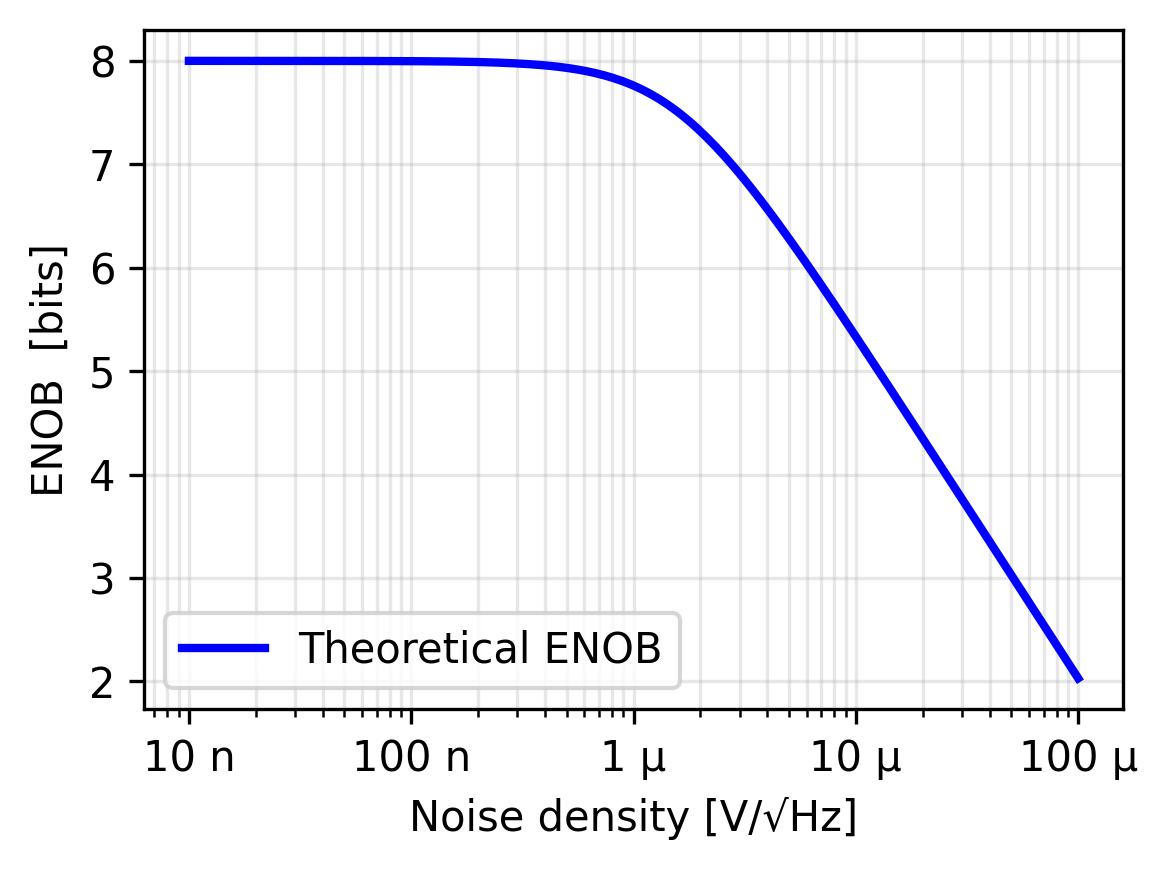

In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from matplotlib.ticker import EngFormatter

"""Import simulated data (tsv)"""
# df = pd.read_csv("cad9.tsv", sep="\t", header=None)
# nd_sim   = df.iloc[:, 0].values
# enob_sim = df.iloc[:, 1].values

# ADC parameters
N    = 8
VFS  = 1.0
fs   = 1e6

# Derived
LSB   = VFS / 2**N
Pq    = LSB**2 / 12            # quantization noise power
Ps    = VFS**2 / 8             # full-scale sinusoid signal power
P_nd  = Pq                     # ideal case: noise+distortion = quantization only

# Sweep nd [V/sqrt(Hz)]
nd = np.logspace(-8, -4, 200)

SNDR_dB = 10 * np.log10(Ps / (P_nd + nd**2 * fs/2))
ENOB    = (SNDR_dB - 1.76) / 6.02

# Plot
plt.figure(figsize=(4, 3), dpi=300)
plt.semilogx(nd, ENOB, 'b-', linewidth=2, label='Theoretical ENOB')
# plt.semilogx(nd_sim, enob_sim, 'r--', linewidth=1, label='Simulated ENOB')
# plt.semilogx(nd_sim, enob_sim, 'ro', markersize=4, markerfacecolor='none')
plt.xlabel('Noise density [V/√Hz]')
plt.gca().xaxis.set_major_formatter(EngFormatter(places=0))
plt.ylabel('ENOB  [bits]')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()